In [1]:
# Compare shared diagonal Gaussian HMMs using brain data only.
from pathlib import Path
from itertools import combinations
import json
import os
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from joblib import Parallel, delayed, parallel_config
from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import KFold

SEED = 28
K_VALUES = range(3, 16)
N_FOLDS = 5
N_INITIALIZATIONS = 10
PLATEAU_GAIN = 0.01
PLATEAU_STEPS = 2
N_JOBS = min(8, os.cpu_count() or 1)

cwd = Path.cwd()
ROOT = cwd if (cwd / "data" / "raw").exists() else cwd.parent
RAW = ROOT / "data" / "raw"
TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
assert RAW.exists(), f"Could not find data/raw from {cwd}"
sns.set_theme(style="ticks", context="notebook")

In [2]:
def session_number(path):
    return int(re.search(r"ses-(\d+)", path.name).group(1))


def contiguous_runs(valid):
    changes = np.diff(np.r_[False, valid, False].astype(int))
    return list(zip(np.flatnonzero(changes == 1), np.flatnonzero(changes == -1)))


def standardize_session(x):
    valid = ~np.isnan(x).any(axis=1)
    observed = x[valid]
    z = np.full(x.shape, np.nan, dtype=float)
    z[valid] = (observed - observed.mean(axis=0)) / observed.std(axis=0, ddof=1)
    return z, valid


def session_sequences(session):
    return [session["z"][start:stop] for start, stop in contiguous_runs(session["valid"])]


def combine(sequences):
    return np.vstack(sequences), [len(sequence) for sequence in sequences]

In [3]:
files = sorted(RAW.glob("*.npy"), key=session_number)[:30]
sessions = []
for path in files:
    x = np.load(path).T
    z, valid = standardize_session(x)
    sessions.append({"session": session_number(path), "z": z, "valid": valid})

assert len(sessions) == 30
assert all(item["z"].shape == (820, 100) for item in sessions)
[(item["session"], len(contiguous_runs(item["valid"]))) for item in sessions[:5]]

[(1, 1), (2, 1), (3, 2), (4, 1), (5, 2)]

In [4]:
# Split entire sessions and retain the 100 standardized parcel features.
fold_rows = []
fold_data = {}
splitter = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for fold, (train_idx, test_idx) in enumerate(splitter.split(sessions), start=1):
    train_sequences = [sequence for i in train_idx for sequence in session_sequences(sessions[i])]
    test_sequences = [sequence for i in test_idx for sequence in session_sequences(sessions[i])]
    train_x, train_lengths = combine(train_sequences)
    test_x, test_lengths = combine(test_sequences)
    fold_data[fold] = {
        "train_x": train_x, "train_lengths": train_lengths,
        "test_x": test_x, "test_lengths": test_lengths,
    }
    fold_rows.append({
        "fold": fold, "split_seed": SEED,
        "train_sessions": json.dumps([sessions[i]["session"] for i in train_idx]),
        "test_sessions": json.dumps([sessions[i]["session"] for i in test_idx]),
        "n_train_trs": len(train_x), "n_test_trs": len(test_x),
        "n_train_sequences": len(train_lengths), "n_test_sequences": len(test_lengths),
        "representation": "parcels", "n_features": 100,
        "variance_retained": 1.0,
    })

folds = pd.DataFrame(fold_rows)
folds.to_csv(TABLES / "hmm_cv_folds_parcels.csv", index=False)
folds

,fold,split_seed,train_sessions,test_sessions,n_train_trs,n_test_trs,n_train_sequences,n_test_sequences,representation,n_features,variance_retained
0,1,28,"[1, 2, 3, 4, 6, 7, 8, 9, 12, 13, 15, 16, 17, 1...","[5, 10, 11, 14, 22, 24]",19591,4879,49,18,parcels,100,1.0
1,2,28,"[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, ...","[7, 8, 16, 18, 19, 30]",19564,4906,57,10,parcels,100,1.0
2,3,28,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 13, 14, 16, 18, ...","[3, 9, 12, 15, 17, 28]",19582,4888,52,15,parcels,100,1.0
3,4,28,"[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 1...","[4, 13, 20, 25, 27, 29]",19577,4893,54,13,parcels,100,1.0
4,5,28,"[3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...","[1, 2, 6, 21, 23, 26]",19566,4904,56,11,parcels,100,1.0


In [5]:
def fit_one(k, fold, initialization, seed):
    data = fold_data[fold]
    started = time.perf_counter()
    result = {"k": k, "fold": fold, "initialization": initialization, "seed": seed}
    try:
        model = GaussianHMM(
            n_components=k, covariance_type="diag", n_iter=200, tol=1e-3,
            min_covar=1e-3, random_state=seed, implementation="log",
        )
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            warnings.simplefilter("ignore", DeprecationWarning)
            model.fit(data["train_x"], data["train_lengths"])
            train_ll, train_posterior = model.score_samples(data["train_x"], data["train_lengths"])
            test_ll, test_posterior = model.score_samples(data["test_x"], data["test_lengths"])
        train_occupancy = train_posterior.mean(axis=0)
        test_occupancy = test_posterior.mean(axis=0)
        result.update({
            "status": "ok", "converged": bool(model.monitor_.converged),
            "n_iterations": int(model.monitor_.iter),
            "train_log_likelihood": train_ll, "test_log_likelihood": test_ll,
            "train_log_likelihood_per_tr": train_ll / len(data["train_x"]),
            "test_log_likelihood_per_tr": test_ll / len(data["test_x"]),
            "train_occupancies": json.dumps(train_occupancy.tolist()),
            "test_occupancies": json.dumps(test_occupancy.tolist()),
            "state_means": json.dumps(model.means_.tolist()),
            "min_train_occupancy": train_occupancy.min(),
            "min_test_occupancy": test_occupancy.min(),
            "warning_count": len({str(item.message) for item in caught}),
            "warnings": " | ".join(sorted({str(item.message) for item in caught})),
            "error": "",
        })
    except Exception as error:
        result.update({"status": "error", "converged": False, "error": repr(error)})
    result["elapsed_seconds"] = time.perf_counter() - started
    return result

In [6]:
# Every seed is deterministic and uniquely identifies K, fold, and initialization.
jobs = [
    (k, fold, initialization, SEED * 1_000_000 + k * 10_000 + fold * 100 + initialization)
    for k in K_VALUES
    for fold in range(1, N_FOLDS + 1)
    for initialization in range(1, N_INITIALIZATIONS + 1)
]
started = time.perf_counter()
with parallel_config(backend="loky", inner_max_num_threads=1):
    records = Parallel(n_jobs=N_JOBS, verbose=5)(delayed(fit_one)(*job) for job in jobs)
results = pd.DataFrame(records).sort_values(["k", "fold", "initialization"]).reset_index(drop=True)
results = results.merge(folds, on="fold", validate="many_to_one")
results.to_csv(TABLES / "hmm_model_selection_parcels_full.csv", index=False)
assert len(results) == len(K_VALUES) * N_FOLDS * N_INITIALIZATIONS
assert results["seed"].nunique() == len(results)
print(f"Completed {len(results)} fits in {(time.perf_counter() - started) / 60:.1f} minutes")
results.groupby(["status", "converged"], dropna=False).size().rename("fits")

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    5.8s


[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   30.2s


[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:  2.2min


[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:  9.7min


[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed: 30.2min


[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed: 63.3min


[Parallel(n_jobs=8)]: Done 650 out of 650 | elapsed: 65.9min finished


Completed 650 fits in 65.6 minutes


status  converged
ok      True         650
Name: fits, dtype: int64

In [7]:
# Within each K and fold, evaluate the initialization with the best training fit.
valid_results = results.query("status == 'ok' and converged").copy()
best_index = valid_results.groupby(["k", "fold"])["train_log_likelihood_per_tr"].idxmax()
selected = valid_results.loc[best_index].sort_values(["k", "fold"]).reset_index(drop=True)
assert len(selected) == len(K_VALUES) * N_FOLDS, "At least one K/fold has no converged fit."
selected.to_csv(TABLES / "hmm_model_selection_parcels_selected_initializations.csv", index=False)

summary = selected.groupby("k").agg(
    mean_test_log_likelihood_per_tr=("test_log_likelihood_per_tr", "mean"),
    sd_test_log_likelihood_per_tr=("test_log_likelihood_per_tr", "std"),
    mean_min_test_occupancy=("min_test_occupancy", "mean"),
    minimum_test_occupancy=("min_test_occupancy", "min"),
    converged_folds=("fold", "nunique"),
).reset_index()
summary.to_csv(TABLES / "hmm_model_selection_parcels_summary.csv", index=False)
summary.round(4)

,k,mean_test_log_likelihood_per_tr,sd_test_log_likelihood_per_tr,mean_min_test_occupancy,minimum_test_occupancy,converged_folds
0,3,-130.4850,0.7776,0.2717,0.2645,5
1,4,-128.2830,0.8146,0.2072,0.2032,5
2,5,-126.8819,0.8946,0.1319,0.1163,5
3,6,-125.5933,0.7297,0.1163,0.1087,5
4,7,-124.8885,0.7765,0.0778,0.0552,5
5,8,-124.0499,0.8165,0.0467,0.0268,5
6,9,-123.3838,0.7999,0.0334,0.0229,5
7,10,-122.7671,0.8452,0.0254,0.0162,5
8,11,-122.3247,0.8572,0.0230,0.0162,5
9,12,-121.9184,0.9178,0.0164,0.0090,5


In [8]:
# Match states for every pair of initializations within the same K and fold.
def matched_cosine_similarity(left, right):
    left = left / np.clip(np.linalg.norm(left, axis=1, keepdims=True), 1e-12, None)
    right = right / np.clip(np.linalg.norm(right, axis=1, keepdims=True), 1e-12, None)
    similarities = left @ right.T
    left_index, right_index = linear_sum_assignment(-similarities)
    return similarities[left_index, right_index]


stability_rows = []
for (k, fold), group in valid_results.groupby(["k", "fold"]):
    for (_, left), (_, right) in combinations(group.iterrows(), 2):
        matched = matched_cosine_similarity(
            np.asarray(json.loads(left["state_means"])),
            np.asarray(json.loads(right["state_means"])),
        )
        stability_rows.append({
            "k": k, "fold": fold,
            "initialization_a": left["initialization"], "seed_a": left["seed"],
            "initialization_b": right["initialization"], "seed_b": right["seed"],
            "mean_matched_cosine": matched.mean(),
            "median_matched_cosine": np.median(matched),
            "minimum_matched_cosine": matched.min(),
        })

stability_pairs = pd.DataFrame(stability_rows)
assert len(stability_pairs) == len(K_VALUES) * N_FOLDS * 45
stability_pairs.to_csv(TABLES / "hmm_model_selection_parcels_stability_pairs.csv", index=False)
stability_summary = stability_pairs.groupby("k").agg(
    mean_matched_cosine=("mean_matched_cosine", "mean"),
    sd_matched_cosine=("mean_matched_cosine", "std"),
    minimum_pair_similarity=("mean_matched_cosine", "min"),
    seed_pairs=("mean_matched_cosine", "size"),
).reset_index()
stability_summary.to_csv(TABLES / "hmm_model_selection_parcels_stability_summary.csv", index=False)
stability_summary.round(3)

,k,mean_matched_cosine,sd_matched_cosine,minimum_pair_similarity,seed_pairs
0,3,1.000,0.000,1.000,225
1,4,1.000,0.000,1.000,225
2,5,1.000,0.000,1.000,225
3,6,1.000,0.000,1.000,225
4,7,0.972,0.055,0.820,225
5,8,0.975,0.046,0.846,225
6,9,0.973,0.043,0.878,225
7,10,0.971,0.042,0.866,225
8,11,0.998,0.004,0.971,225
9,12,0.983,0.030,0.877,225


In [9]:
# Plateau: two consecutive mean gains below 0.01 held-out log-likelihood units per valid TR.
gain_rows = []
for fold, group in selected.groupby("fold"):
    group = group.sort_values("k")
    for previous, current in zip(group.iloc[:-1].itertuples(), group.iloc[1:].itertuples()):
        gain_rows.append({
            "fold": fold, "from_k": previous.k, "to_k": current.k,
            "heldout_gain_per_tr": current.test_log_likelihood_per_tr - previous.test_log_likelihood_per_tr,
        })
likelihood_gains = pd.DataFrame(gain_rows)
assert len(likelihood_gains) == (len(K_VALUES) - 1) * N_FOLDS
likelihood_gains.to_csv(TABLES / "hmm_model_selection_parcels_likelihood_gains.csv", index=False)
gain_summary = likelihood_gains.groupby(["from_k", "to_k"]).agg(
    mean_gain_per_tr=("heldout_gain_per_tr", "mean"),
    sd_gain_per_tr=("heldout_gain_per_tr", "std"),
    minimum_gain_per_tr=("heldout_gain_per_tr", "min"),
    positive_folds=("heldout_gain_per_tr", lambda values: (values > 0).sum()),
).reset_index()
below = gain_summary["mean_gain_per_tr"].lt(PLATEAU_GAIN).to_numpy()
starts = [index for index in range(len(below) - PLATEAU_STEPS + 1) if below[index:index + PLATEAU_STEPS].all()]
plateau_k = int(gain_summary.iloc[starts[0]]["from_k"]) if starts else None
gain_summary.to_csv(TABLES / "hmm_model_selection_parcels_likelihood_gain_summary.csv", index=False)
print(f"Plateau K under the prespecified rule: {plateau_k}")
gain_summary.round(4)

Plateau K under the prespecified rule: None


,from_k,to_k,mean_gain_per_tr,sd_gain_per_tr,minimum_gain_per_tr,positive_folds
0,3,4,2.2020,0.1178,2.0372,5
1,4,5,1.4011,0.1287,1.2067,5
2,5,6,1.2886,0.2040,1.0424,5
3,6,7,0.7048,0.1616,0.4455,5
4,7,8,0.8385,0.0626,0.7602,5
5,8,9,0.6662,0.0351,0.6306,5
6,9,10,0.6167,0.0777,0.5640,5
7,10,11,0.4423,0.0528,0.3871,5
8,11,12,0.4064,0.0779,0.2993,5
9,12,13,0.4438,0.0620,0.4081,5


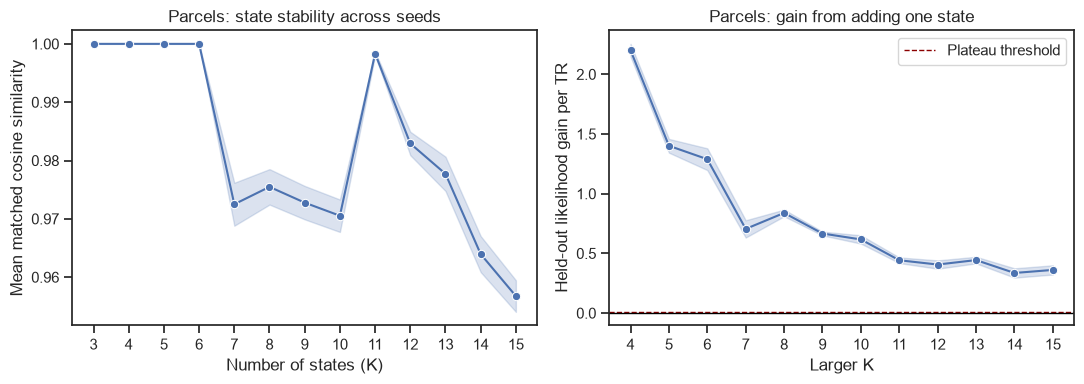

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=stability_pairs, x="k", y="mean_matched_cosine", marker="o", errorbar=("se", 1), ax=axes[0])
sns.lineplot(data=likelihood_gains, x="to_k", y="heldout_gain_per_tr", marker="o", errorbar=("se", 1), ax=axes[1])
axes[0].set(title="Parcels: state stability across seeds", xlabel="Number of states (K)", ylabel="Mean matched cosine similarity", xticks=list(K_VALUES))
axes[1].axhline(PLATEAU_GAIN, color="darkred", linestyle="--", linewidth=1, label="Plateau threshold")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Parcels: gain from adding one state", xlabel="Larger K", ylabel="Held-out likelihood gain per TR", xticks=list(range(4, 16)))
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / "hmm_cv_parcels_stability_and_likelihood_gains.png", dpi=180, bbox_inches="tight")

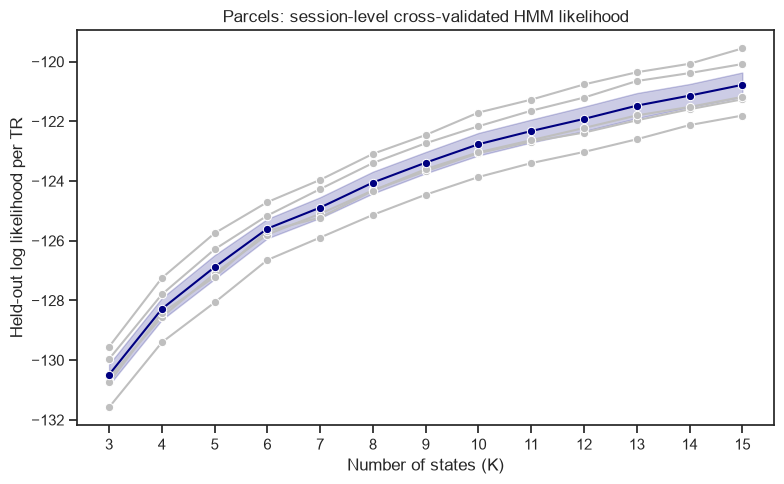

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=selected, x="k", y="test_log_likelihood_per_tr", units="fold", estimator=None, color="0.75", marker="o", ax=ax)
sns.lineplot(data=selected, x="k", y="test_log_likelihood_per_tr", color="navy", marker="o", errorbar=("se", 1), ax=ax)
ax.set(title="Parcels: session-level cross-validated HMM likelihood", xlabel="Number of states (K)", ylabel="Held-out log likelihood per TR", xticks=list(K_VALUES))
fig.tight_layout()
fig.savefig(FIGURES / "hmm_cv_parcels_heldout_likelihood.png", dpi=180, bbox_inches="tight")

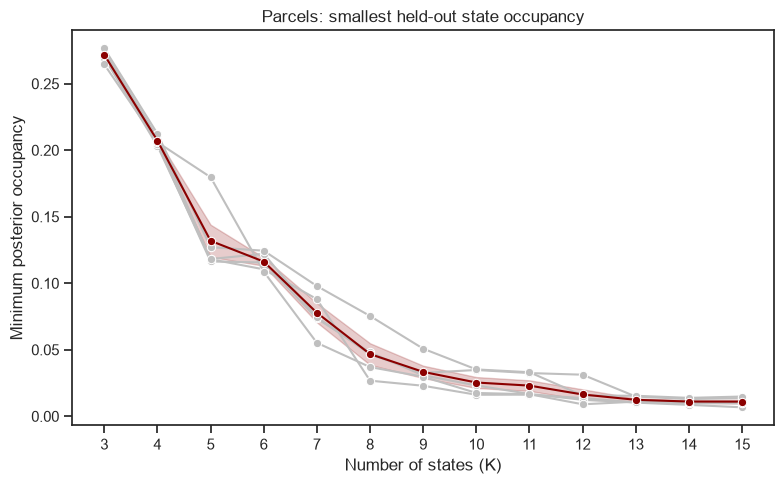

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=selected, x="k", y="min_test_occupancy", units="fold", estimator=None, color="0.75", marker="o", ax=ax)
sns.lineplot(data=selected, x="k", y="min_test_occupancy", color="darkred", marker="o", errorbar=("se", 1), ax=ax)
ax.set(title="Parcels: smallest held-out state occupancy", xlabel="Number of states (K)", ylabel="Minimum posterior occupancy", xticks=list(K_VALUES))
fig.tight_layout()
fig.savefig(FIGURES / "hmm_cv_parcels_minimum_state_occupancy.png", dpi=180, bbox_inches="tight")

In [13]:
diagnostics = pd.Series({
    "fits requested": len(jobs),
    "fits completed": results["status"].eq("ok").sum(),
    "fits converged": results["converged"].fillna(False).sum(),
    "fold-K combinations represented": selected.groupby(["k", "fold"]).ngroups,
    "state-stability seed pairs": len(stability_pairs),
    "plateau K": plateau_k,
    "final K selected": "No; inspect likelihood, occupancy, and stability diagnostics together",
}, name="model-selection diagnostics")
diagnostics

fits requested                                                                   650
fits completed                                                                   650
fits converged                                                                   650
fold-K combinations represented                                                   65
state-stability seed pairs                                                      2925
plateau K                                                                       None
final K selected                   No; inspect likelihood, occupancy, and stabili...
Name: model-selection diagnostics, dtype: object